In [38]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, TargetEncoder
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score,classification_report,r2_score

In [39]:
df = pd.read_csv("Titanic-Dataset.csv")

In [40]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [41]:
df.corr(numeric_only = True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [42]:
df.dropna(inplace=True)

# we are not performing any eda because we are firstly trying to learn how do we use models

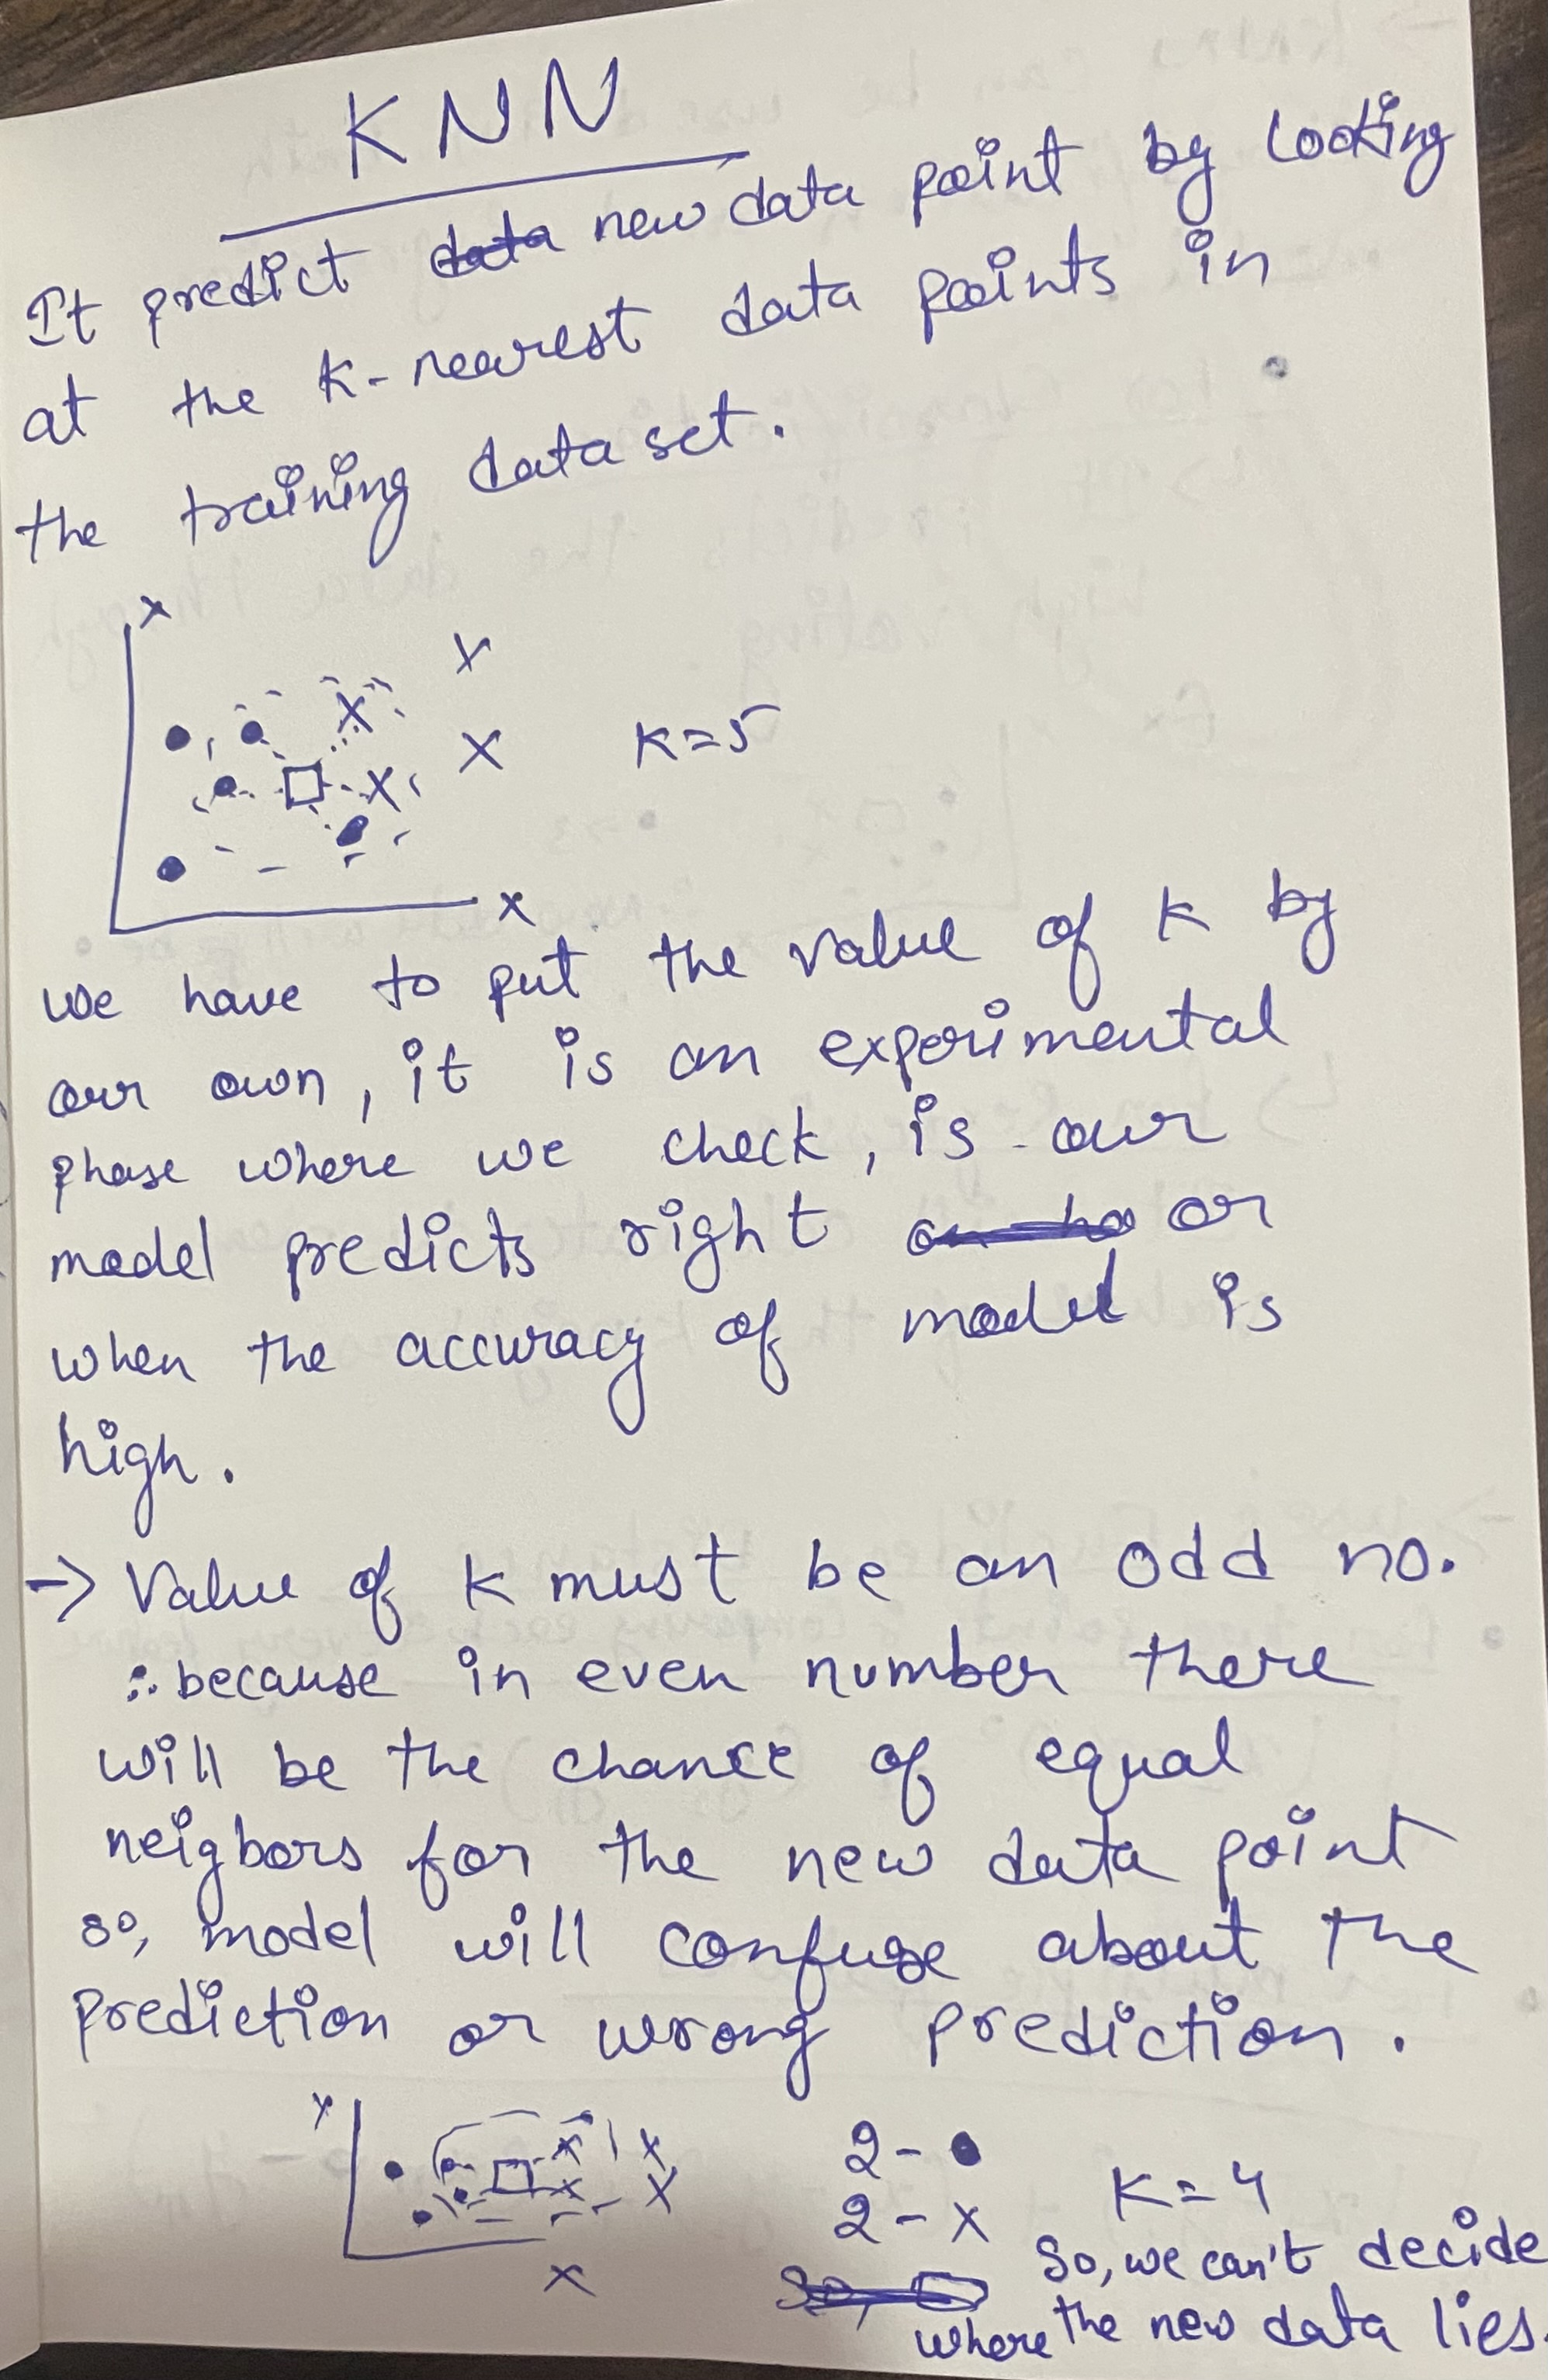
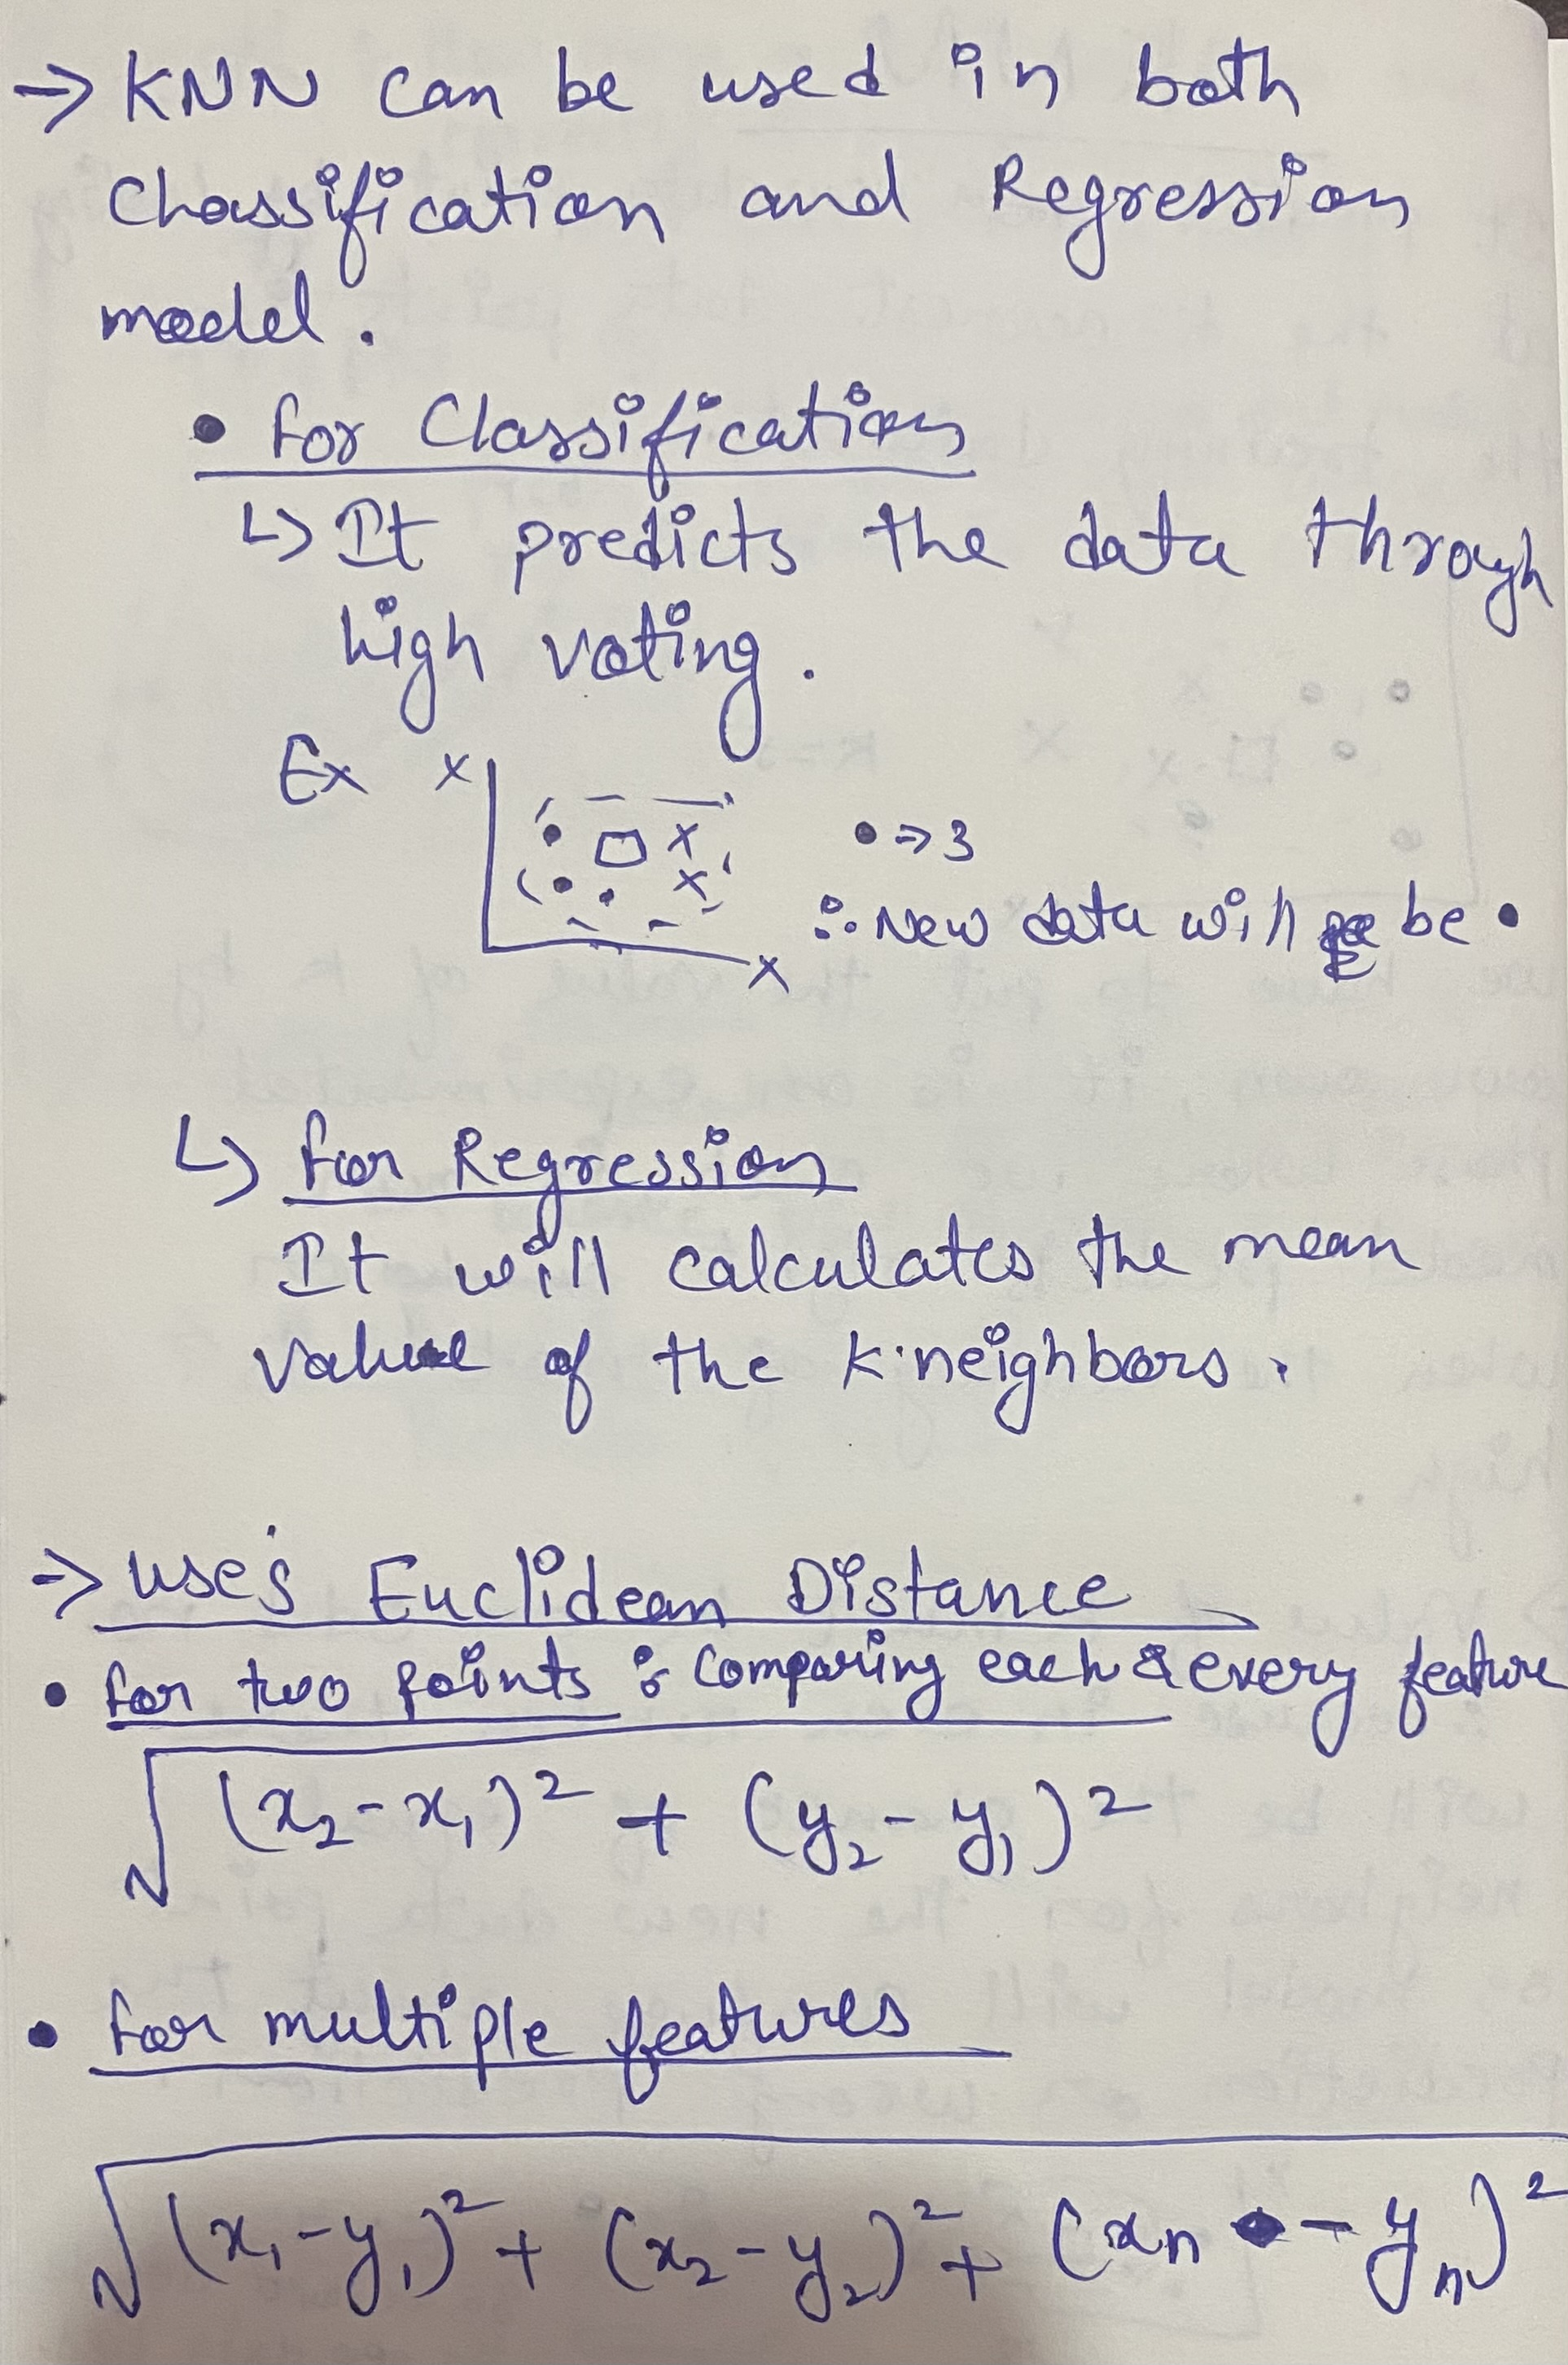

In [43]:
x = df.drop(columns=['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'])

In [44]:
label = LabelEncoder()
x['Embarked'] = label.fit_transform(x['Embarked'])

In [45]:
x['Sex'] = label.fit_transform(x['Sex'])

impute = SimpleImputer(strategy="median")
x = impute.fit_transform(x)

scale = StandardScaler()
x = scale.fit_transform(x)

In [46]:
y = df['Survived']

In [47]:
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=76, test_size=0.2 )

In [48]:
model = KNeighborsClassifier(n_neighbors=5)

model.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [49]:
y_pred = model.predict(x_test)

In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.67      0.67        12
           1       0.84      0.84      0.84        25

    accuracy                           0.78        37
   macro avg       0.75      0.75      0.75        37
weighted avg       0.78      0.78      0.78        37



In [51]:
# for regression

In [52]:
df2 = pd.read_csv("housing.csv")

In [53]:
df2.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY


In [54]:
def build_pipeline(num_att, cat_att): 

    cat_pipe = Pipeline([
        ("OneHot", OneHotEncoder(handle_unknown="ignore"))
    ])
    
    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("stand", StandardScaler())
    ])

    full_pipe = ColumnTransformer([
        ("cat", cat_pipe, cat_att),
        ("num", num_pipe, num_att) 
        
    ])
    return full_pipe

In [55]:
x = df2.drop('median_house_value', axis=1) 
y = df2['median_house_value']

num_att = x.drop('ocean_proximity', axis=1).columns.to_list()
cat_att = ['ocean_proximity'] 


pipeline = build_pipeline(num_att, cat_att)
x_transformed = pipeline.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x_transformed,y, random_state=42, test_size=0.2)

In [56]:
reg_model = KNeighborsRegressor(n_neighbors=7)

In [57]:
reg_model.fit(x_train, y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [58]:
y_re_pred = reg_model.predict(x_test)

In [59]:
r2_score(y_test, y_re_pred)

0.7149539582514137